In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
installed = 0

# imports

In [2]:
import os

if not installed:
    print("🔧 Step 1: Upgrading core packages...")
    print("="*70)
    !pip install -q --upgrade pip
    print("Updated 'pip' package...!")
    !pip install -q --upgrade google-cloud-vision
    print("Updated 'google cloud vision' package...!")
    !pip install -q --upgrade pip ipywidgets
    print("✅ Core packages upgraded.\n")
    
    print("🚀 Step 2: Installing/upgrading performance libraries (bitsandbytes, accelerate, transformers)...")
    print("="*70)
    !pip install -q -U bitsandbytes
    print("Updated 'bitsandbytes' package...!")
    !pip install -q -U accelerate
    print("Updated 'accelerate' package...!")
    !pip install -q -U transformers
    print("Updated 'transformers' package...!")
    print("✅ Performance libraries installed/upgraded.\n")
    
    print("🧠 Step 3: Installing OpenAI CLIP from GitHub...")
    print("="*70)
    !pip install -q git+https://github.com/openai/CLIP.git
    print("✅ OpenAI CLIP installed.\n")
    
    print("="*70)
    print("✅ All installations completed successfully!")
    print("🔄 Restarting kernel to apply changes...")
    # os.kill(os.getpid(), 9)
    installed = 1
else:
    print("All up to date!")

🔧 Step 1: Upgrading core packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.9 MB/s eta 0:00:0000:0100:01
Updated 'pip' package...!
Updated 'google cloud vision' package...!
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.1.0 which is incompatible.
✅ Core packages upgraded.

🚀 Step 2: Installing/upgrading performance libraries (bitsandbytes, accelerate, transformers)...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcug

In [ ]:
os.kill(os.getpid(), 9)

In [2]:
import transformers
print(transformers.__version__)

4.57.0


In [3]:
# All Imports
# ----------------------------------------- GOOGLE OCR API -------------------------------------------
from google.cloud import vision
import io
from io import BytesIO

# ---------------------------------------- ESSENTIAL IMPORTS -----------------------------------------
import os
import time
import requests
import chardet
from tqdm.notebook import tqdm
import random

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy.stats import mode

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError
import ast

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score

# ------------------------------------- DistilRoBERTa IMPORTS ----------------------------------------
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# ----------------------------------------- BLIP IMPORTS ---------------------------------------------
from transformers import BlipProcessor, BlipForConditionalGeneration

# ----------------------------------------- CLIP IMPORTS ---------------------------------------------
import clip

# ----------------------------------------- Torch IMPORTS --------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

print("\n","="*50)
print("All imports successful!")

2025-10-10 15:44:29.076375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760111069.476089     157 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760111069.608228     157 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



All imports successful!


In [4]:
# ----------------------------------------- Essentials ---------------------------------------------
# Replace with your actual path to the JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/kaggle/input/musait/manifest-canto-466706-v0-1bb68556dfe3.json"


SENTIMENTS_TO_LABELS = {'negative':0,'neutral':1,'positive':2}
LABELS_TO_SENTIMENTS = {0:'negative',1:'neutral',2:"positive"}


# text_model_name = "distilroberta-base"
# text_model_name = "roberta-base"
text_model_name = "t5-base"
# text_model_name = "facebook/bart-base"

blip_model_name = "Salesforce/blip-image-captioning-base"

image_model_name = "ViT-B/32" # CLIP
# image_model_name = "xception"
# image_model_name = "ViT-L/16"

MAX_LENGTH = 128
num_classes = 3
embed_dim = 512


# Set the device to GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Google OCR environment ready to use!")

Google OCR environment ready to use!


In [5]:
name2model = {
    "distilroberta-base" : "/kaggle/input/best-models-musait/TSA/DistilRoBERTa__best_model.pt",
    "roberta-base" : "/kaggle/input/best-models-musait/TSA/RoBERTa__best_model.pt",
    "t5-base" : "/kaggle/input/best-models-musait/TSA/T5__best_model.pt",
    "facebook/bart-base" : "/kaggle/input/best-models-musait/TSA/bart__best_model.pt",
    "ViT-B/32" : "/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt",
    "vit_large_patch16_224" : "/kaggle/input/best-models-musait/VSA/ViT-L__best_model.pt",
    "xception" : "/kaggle/input/best-models-musait/VSA/Xception__best_model.pt"
}

model2stdName = {
    "distilroberta-base" : "DistilRoBERTa",
    "roberta-base" : "RoBERTa",
    "t5-base" : "T5",
    "facebook/bart-base" : "BART",
    "ViT-B/32" : "CLIP",
    "vit_large_patch16_224" : "ViT-L/16",
    "xception" : "Xception"
}

# __ init __

In [6]:
# ================================ TEXT DETECTION ================================================

def check_text_detection_v1(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts[0] if texts else False

def check_text_detection_v2(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts if texts else False


# ================================ STANDARD ASPECT RATII ================================================

standard_ratios = {
    "1:1": 1.0,       # 1
    "4:3": 4/3,       # 1.33
    "3:2": 3/2,       # 1.5
    "16:9": 16/9,     # 1.78
    "5:4": 5/4,       # 1.25
    "21:9": 21/9,     # 2.33
    "2:1": 2.0,       # 2
    "7:5": 7/5,       # 1.4
    "1.41:1": 1.41,   # 1.41 (A4)
    "3:4": 3/4,       # 0.75
    "2:3": 2/3,       # 0.67
    "9:16": 9/16,     # 0.5625
    "5:7": 5/7,       # 0.71
    "4:5": 4/5,       # 0.8
    "1:√2": 1/1.414,  # 0.707 (A-series)
    "2:5": 2/5,       # 0.4
    "Other": 0
}


def closest_standard_ratio(width, height, tolerance=0.05):
    if height == 0:
        return "Invalid"
    ratio = width / height
    for name, std_ratio in standard_ratios.items():
        if abs(ratio - std_ratio) <= tolerance:
            return name
    return "Other"


# ================================ ASPECT RATIO - ORIENTATION ==========================================
    
aspect_ratio_orientation = {
    "1:1": "box",
    "4:3": "horizontal",      # 1.33
    "3:2": "horizontal",      # 1.5
    "16:9": "horizontal",     # 1.78
    "5:4": "horizontal",      # 1.25
    "21:9": "horizontal",     # 2.33
    "2:1": "horizontal",      # 2.0
    "7:5": "horizontal",      # 1.4
    "1.41:1": "horizontal",   # 1.41
    "3:4": "vertical",        # 0.75
    "2:3": "vertical",        # 0.666
    "9:16": "vertical",       # 0.5625
    "5:7": "vertical",        # 0.714
    "4:5": "vertical",        # 0.8
    "1:√2": "vertical",       # 0.707 (A-series)
    "2:5": "vertical",        # 0.4
    "Other": "box"
}

def image_orientation(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    pil_image = Image.open(io.BytesIO(content))
    img_width, img_height = pil_image.size
    
    img_area = img_width * img_height
    img_ar = closest_standard_ratio(img_width, img_height)
    img_ort = aspect_ratio_orientation[img_ar]
    img_ort_sentiments = list(or_dist[img_ort])
    return img_ort_sentiments


def get_image_area(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    pil_image = Image.open(io.BytesIO(content))
    img_width, img_height = pil_image.size
    img_area = img_width*img_height
    return img_area

def get_alpha_v2(texts, img_area):
    total_text_area = 0
    for t in texts[1:]:
        vertices = [(v.x, v.y) for v in t.bounding_poly.vertices]
        text_area = polygon_area(vertices)
        total_text_area += text_area
        print(f"Word: {t.description}, Area: {text_area}")
    
    print("Total Area:", total_text_area)
    alpha = total_text_area/img_area
    return alpha


def get_alpha_v1(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    return txt_weightage

def text_orientation(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    txt_ar = closest_standard_ratio(txt_width, txt_height)
    txt_ort = aspect_ratio_orientation[txt_ar]
    txt_ort_sentiments = list(or_dist[txt_ort])
    return txt_ort_sentiments, txt_weightage


# ========================================== TEXT MODEL ================================================

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(text_model_name)
text_model = AutoModelForSequenceClassification.from_pretrained(text_model_name, num_labels=num_classes)

text_model.to(device)

# Load your fine-tuned weights
state_dict = torch.load(name2model[text_model_name], map_location=device)
text_model.load_state_dict(state_dict)  # Should match now
text_model.eval()

def preprocess(text, tokenizer, max_length=128):
    return tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )


text_tokenizer = AutoTokenizer.from_pretrained(text_model_name)



# ================================ GENERATION OF CAPTIONS ==============================================


blip_processor = BlipProcessor.from_pretrained(blip_model_name)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_model_name).to(device)

blip_model.to(device)


# ========================================= IMAGE MODEL ================================================

class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)  # usually float16
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()  # Convert back to float32 for classifier
        return self.classifier(x)

clip_model, image_preprocess = clip.load(image_model_name, device=device)
image_encoder = clip_model.visual

image_model = CLIPClassifier(image_encoder, embed_dim=embed_dim, num_classes=num_classes).to(device)

image_model.load_state_dict(torch.load("/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt"))
image_model.eval()

print("\n","="*50)
print("All initializations successful...!!")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at t5-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]


  0%|                                               | 0.00/338M [00:00<?, ?iB/s]
  0%|                                      | 1.03M/338M [00:00<00:33, 10.6MiB/s]
  2%|▋                                     | 6.50M/338M [00:00<00:09, 37.3MiB/s]
  4%|█▋                                    | 14.9M/338M [00:00<00:05, 60.4MiB/s]
  6%|██▎                                   | 20.7M/338M [00:00<00:06, 52.1MiB/s]
  8%|██▉                                   | 26.2M/338M [00:00<00:06, 53.1MiB/s]
 10%|███▉                                  | 35.4M/338M [00:00<00:04, 64.3MiB/s]
 12%|████▋                                 | 41.6M/338M [00:00<00:05, 59.2MiB/s]
 14%|█████▎                                | 47.4M/338M [00:00<00:05, 56.3MiB/s]
 16%|█████▉                                | 52.8M/338M [00:01<00:06, 43.7MiB/s]
 17%|██████▍                               | 57.4M/338M [00:01<00:06, 42.9MiB/s]
 18%|██████▉                               | 61.7M/338M [00:01<00:07, 38.5MiB/s]
 19%|███████▍              


All initializations successful...!!


# MuSAIT Model

In [7]:
def MuSAIT_original(filepath, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info = False):
    text = None
    texts = check_text_detection_v1(filepath)
    # alpha = 0.5
    # alpha = 0.11006431308155445
    alpha = None
    img_area = get_image_area(filepath)
    td = 1 if texts else 0
    if texts:
        text = texts.description
        alpha = round(get_alpha_v1(texts, img_area), 2)
        # print(f"alpha = {alpha}")
    else:
        if print_info:
            print("-"*100)
            print("Caution: There exists no text inside image. Predictions might be flawed!")
            print("-"*100)
            time.sleep(1) # 1000 ms
            print("Generating caption for the image...")
            print("Loading...!")
            time.sleep(1) # 1000 ms
            print("Almost there...")
            time.sleep(1) # 1000 ms
        # BLIP-2 Image Caption Generation
        raw_image = Image.open(filepath).convert('RGB')
        inputs = blip_processor(images=raw_image, return_tensors="pt").to(device, torch.float16)
        generated_ids = blip_model.generate(**inputs)
        text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        if not return_value:
            print(f"Generated image caption: {text}")
        alpha = 0.5

    # DistilRoBERTa tokenization
    inputs = text_tokenizer(text, return_tensors="pt", 
                            truncation=True, 
                            padding=True, 
                            max_length=MAX_LENGTH).to(device)
    # print(f"inputs['input_ids'].shape == inputs['attention_mask'].shape is {inputs['input_ids'].shape == inputs['attention_mask'].shape}")
    with torch.no_grad():
        outputs = text_model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    prob_text = np.array(probs.squeeze().tolist())
    pred_class_text = np.argmax(prob_text)

    image = None 
    image_preprocessed = None
    try:
        image = Image.open(filepath).convert("RGB")
        image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
        print(f"File: {ID}.jpg is an INVALID image file")
        return -1
    except Exception as e:
        print(f"Unexpected error: {e}")
        return -1
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    # print(f"prob_total = {alpha} * {prob_text} + ({1 - alpha}) * {prob_img} = {prob_total}")
    pred_class = np.argmax(prob_total)
    if print_info:
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input image")
        plt.show()
        print("_"*50)
        print("RESULTS")
        print("_"*50)
        print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
        print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
        print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
        print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
        print("_"*50)
        print("Thank you!")
    else:
        if return_td:
            return pred_class, td
        else:
            return pred_class

In [8]:
def MuSAIT_noBLIP(filepath, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info=False):
    text = None
    prob_text, prob_img = None, None
    pred_class_text, pred_class_img = None, None
    texts = check_text_detection(filepath)
    # alpha = 0.5
    # alpha = 0.11006431308155445
    alpha = None
    img_area = get_image_area(filepath)
    td = 1 if texts else 0
    if texts:
        text = texts.description
        alpha = round(get_alpha(texts, img_area), 2)
        # print(f"alpha = {alpha}")
        # DistilRoBERTa tokenization
        inputs = text_tokenizer(text, return_tensors="pt", 
                                truncation=True, 
                                padding=True, 
                                max_length=MAX_LENGTH).to(device)
        with torch.no_grad():
            outputs = text_model(**inputs)
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
        
        prob_text = np.array(probs.squeeze().tolist())
        pred_class_text = np.argmax(prob_text)
    else:
        prob_text = np.array([0,0,0])
        pred_class_text = 1
        alpha = 0

    image = None 
    image_preprocessed = None
    try:
        image = Image.open(filepath).convert("RBG")
        image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
        print(f"File: {ID}.jpg is an INVALID image file")
        return -1
    except Exception as e:
        print(f"Unexpected error: {e}")
        return -1
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    # print(f"prob_total = {alpha} * {prob_text} + ({1 - alpha}) * {prob_img} = {prob_total}")
    pred_class = np.argmax(prob_total)
    if print_info:
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input image")
        plt.show()
        print("_"*50)
        print("RESULTS")
        print("_"*50)
        print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
        print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
        print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
        print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
        print("_"*50)
        print("Thank you!")
    else:
        if return_td:
            return pred_class, td
        else:
            return pred_class

In [9]:
def MuSAIT(filepath, generate=0, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info = False):
    if generate:
        MuSAIT_original(filepath, alpha, return_value, return_td, orientation, print_info)
    else:
        MuSAIT_noBLIP(filepath, alpha, return_value, return_td, orientation, print_info)
    return

# MELT

In [10]:
def MELT_B1(filepath, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info = False):
    text = None
    texts = check_text_detection_v1(filepath)
    # alpha = 0.5
    # alpha = 0.11006431308155445
    alpha = None
    img_area = get_image_area(filepath)
    td = 1 if texts else 0
    if texts:
        text = texts.description
        alpha = round(get_alpha_v1(texts, img_area), 2)
        # print(f"alpha = {alpha}")
    else:
        if print_info:
            print("-"*100)
            print("Caution: There exists no text inside image. Predictions might be flawed!")
            print("-"*100)
            time.sleep(1) # 1000 ms
            print("Generating caption for the image...")
            print("Loading...!")
            time.sleep(1) # 1000 ms
            print("Almost there...")
            time.sleep(1) # 1000 ms
        # BLIP-2 Image Caption Generation
        raw_image = Image.open(filepath).convert('RGB')
        inputs = blip_processor(images=raw_image, return_tensors="pt").to(device, torch.float16)
        generated_ids = blip_model.generate(**inputs)
        text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        if not return_value:
            print(f"Generated image caption: {text}")
        alpha = 0.5

    # DistilRoBERTa tokenization
    inputs = text_tokenizer(text, return_tensors="pt", 
                            truncation=True, 
                            padding=True, 
                            max_length=MAX_LENGTH).to(device)
    # print(f"inputs['input_ids'].shape == inputs['attention_mask'].shape is {inputs['input_ids'].shape == inputs['attention_mask'].shape}")
    with torch.no_grad():
        outputs = text_model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    prob_text = np.array(probs.squeeze().tolist())
    pred_class_text = np.argmax(prob_text)

    image = None 
    image_preprocessed = None
    try:
        image = Image.open(filepath)
        image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
        print(f"File: {ID}.jpg is an INVALID image file")
        return -1
    except Exception as e:
        print(f"Unexpected error: {e}")
        return -1
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    # print(f"prob_total = {alpha} * {prob_text} + ({1 - alpha}) * {prob_img} = {prob_total}")
    pred_class = np.argmax(prob_total)
    if print_info:
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input image")
        plt.show()
        print("_"*50)
        print("RESULTS")
        print("_"*50)
        print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
        print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
        print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
        print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
        print("_"*50)
        print("Thank you!")
    else:
        if return_td:
            return pred_class, td
        else:
            return pred_class

In [17]:
def MELT_B0(filepath, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info=False):
    text = None
    prob_text, prob_img = None, None
    pred_class_text, pred_class_img = None, None
    texts = check_text_detection_v1(filepath)
    # alpha = 0.5
    # alpha = 0.11006431308155445
    # alpha = None
    img_area = get_image_area(filepath)
    td = 1 if texts else 0
    if texts:
        text = texts.description
        # alpha = round(get_alpha(texts, img_area), 2)
        # print(f"alpha = {alpha}")
        # DistilRoBERTa tokenization
        inputs = text_tokenizer(text, return_tensors="pt", 
                                truncation=True, 
                                padding=True, 
                                max_length=MAX_LENGTH).to(device)
        with torch.no_grad():
            outputs = text_model(**inputs)
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
        
        prob_text = np.array(probs.squeeze().tolist())
        pred_class_text = np.argmax(prob_text)
    else:
        prob_text = np.array([0,0,0])
        pred_class_text = 1
        # alpha = 0

    image = None 
    image_preprocessed = None
    try:
        image = Image.open(filepath)
        image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)
    except (OSError, UnidentifiedImageError, FileNotFoundError) as e:
        print(f"File: {ID}.jpg is an INVALID image file")
        return -1
    except Exception as e:
        print(f"Unexpected error: {e}")
        return -1
        
    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        pred_class_image = output.argmax(dim=1).item()

    
    prob_total = alpha * prob_text + (1 - alpha) * prob_img
    # print(f"prob_total = {alpha} * {prob_text} + ({1 - alpha}) * {prob_img} = {prob_total}")
    pred_class = np.argmax(prob_total)
    if print_info:
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input image")
        plt.show()
        print("_"*50)
        print("RESULTS")
        print("_"*50)
        print(f"Predicted sentiment : {LABELS_TO_SENTIMENTS[pred_class]}")
        print(f"Confidence score: {prob_total[pred_class]*100:.3f}")
        print(f"\nChannel wise predicted sentiment (text, image): ({LABELS_TO_SENTIMENTS[pred_class_text]},{LABELS_TO_SENTIMENTS[pred_class_image]})")
        print(f"\nChannel wise predicted sentiment (text, image): ({prob_text[pred_class_text]:.3f},{prob_img[pred_class_image]:.3f})")
        print("_"*50)
        print("Thank you!")
    else:
        if return_td:
            return pred_class, td
        else:
            return pred_class

In [18]:
def MELT(filepath, generate=0, alpha=0.5, return_value=False, return_td=False, orientation=False, print_info = False):
    if generate:
        return MELT_B1(filepath, alpha, return_value, return_td, orientation, print_info)
    else:
        return MELT_B0(filepath, alpha, return_value, return_td, orientation, print_info)

# Inference

----------------------------------------------------------------------------------------------------
Caution: There exists no text inside image. Predictions might be flawed!
----------------------------------------------------------------------------------------------------
Generating caption for the image...
Loading...!
Almost there...
Generated image caption: a large building with a fire in the middle


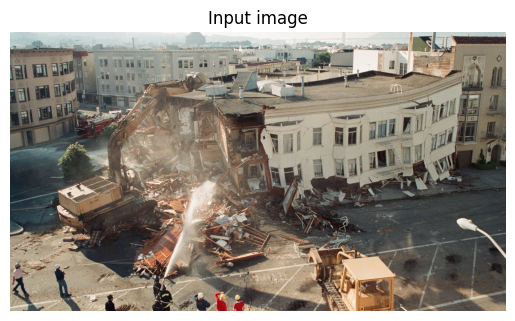

__________________________________________________
RESULTS
__________________________________________________
Predicted sentiment : negative
Confidence score: 94.657

Channel wise predicted sentiment (text, image): (negative,negative)

Channel wise predicted sentiment (text, image): (0.986,0.907)
__________________________________________________
Thank you!


In [13]:
MuSAIT("/kaggle/input/musait/basket_unique/negative_003.jpg", generate=1, print_info=True)

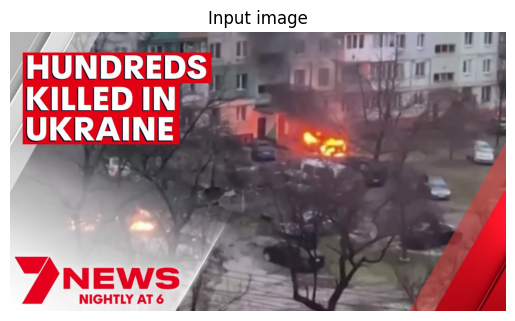

__________________________________________________
RESULTS
__________________________________________________
Predicted sentiment : negative
Confidence score: 96.772

Channel wise predicted sentiment (text, image): (negative,negative)

Channel wise predicted sentiment (text, image): (1.000,0.951)
__________________________________________________
Thank you!


In [14]:
MELT("/kaggle/input/musait/basket_unique/negative_002.jpg", generate=1, print_info=True)

# Alpha

In [15]:
import os

def save_results(filename, cm, support, macro_precision, macro_recall, macro_f1, accuracy, report):
    # Create file name

    # Prepare formatted text
    content = f"""============================================================================
    Model Name: MELT
    ============================================================================
    Confusion Matrix:
    
              Pred 0  Pred 1  Pred 2
    Actual 0     {cm[0][0]}      {cm[0][1]}      {cm[0][2]}
    Actual 1      {cm[1][0]}     {cm[1][1]}      {cm[1][2]}
    Actual 2      {cm[2][0]}      {cm[2][1]}     {cm[2][2]}
    
    Support\t\t: {support}
    Macro precision\t: {macro_precision}
    Macro recall\t: {macro_recall}
    Macro F1\t: {macro_f1}
    Accuracy\t: {accuracy}
    
    Classification Report
    {report}
    """
    
    # Save to file
    with open(filename, "w") as f:
        f.write(content)

    print(f"Results saved to {filename}")

In [26]:
from sklearn.metrics import classification_report

def find_cm_cr(filename, y_true, y_pred):
    TP, FP, FN = [0]*3,[0]*3,[0]*3
    class_precision, class_recall, class_f1 = [0]*3,[0]*3,[0]*3
    classes = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    # print(cm)
    cm_df = pd.DataFrame(cm, index=[f"Actual: {c}" for c in classes],
                        columns=[f"Predicted: {c}" for c in classes])
    print("\nConfusion Matrix:")
    print(cm_df)

    report = classification_report(y_true, y_pred, digits=4) 
    print("Classification report")
    print(report)
    
    for idx, cls in enumerate(classes):
        TP = cm[idx, idx]
        FP = cm[:, idx].sum() - TP
        FN = cm[idx, :].sum() - TP
    
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        class_precision[idx] = precision,
        class_recall[idx] = recall,
        class_f1[idx] = f1
        
    macro_precision = sum(np.array(class_precision))/3
    macro_recall = sum(np.array(class_recall))/3
    macro_f1 = sum(np.array(class_f1))/3
    accuracy = np.trace(cm) / np.sum(cm)
    support = len(y_true)
    print(f"Support : {support}")
    print(f"Macro precision: {macro_precision[0]}")
    print(f"Macro recall: {macro_recall[0]}")
    print(f"Macro F1: {macro_f1}")
    print(f"Accuracy: {accuracy}")
    save_results(filename, cm, support, macro_precision, macro_recall, macro_f1, accuracy, report)
    return accuracy

## Fixed-alpha optimality (MELT)

In [25]:
import warnings

warnings.filterwarnings("ignore")

In [27]:
root = "/kaggle/input/musait/basket_unique"
directory = os.listdir(root)
directory.sort()
L = len(directory)

random.shuffle(directory)

weights = np.arange(0.1,0.9,0.1)
alphas = []
acc = []


print("-"*10,f"MELT Model for optimal alpha","-"*10)

# create tqdm iterator
pbar = tqdm(weights, desc="Finding optimal fixed alpha value")

for alpha in pbar:
    pbar.set_description(f"Finding optimal fixed alpha value alpha={alpha:.2f}")
    
    y_true, y_pred = [],[]
    for fname in tqdm(directory, desc="Running inference of MELT on MuSAIT dataset"):
        filepath = os.path.join(root,fname)
        pred_class = MELT(filepath, alpha=alpha, return_value=True)
        actual_sentiment = fname.split("_")[0]
        actual_class = SENTIMENTS_TO_LABELS[actual_sentiment]
        y_true += [actual_class]
        y_pred += [pred_class]
        # break
    accuracy = find_cm_cr(f"MELT__alpha{alpha}.txt", y_true, y_pred)
    acc += [accuracy]
    # break

print("="*100)
print("Inference complete!")

---------- MELT Model for optimal alpha ----------


Finding optimal fixed alpha value:   0%|          | 0/8 [00:00<?, ?it/s]

Running inference of MELT on MuSAIT dataset:   0%|          | 0/2054 [00:00<?, ?it/s]


Confusion Matrix:
           Predicted: 0  Predicted: 1  Predicted: 2
Actual: 0           567            38            41
Actual: 1            15           632             9
Actual: 2            14            37           701
Classification report
              precision    recall  f1-score   support

           0     0.9513    0.8777    0.9130       646
           1     0.8939    0.9634    0.9274       656
           2     0.9334    0.9322    0.9328       752

    accuracy                         0.9250      2054
   macro avg     0.9262    0.9244    0.9244      2054
weighted avg     0.9264    0.9250    0.9249      2054

Support : 2054
Macro precision: 0.9262274496552022
Macro recall: 0.9244348211794482
Macro F1: 0.924403548993471
Accuracy: 0.9250243427458618
Results saved to MELT__alpha0.1.txt


Running inference of MELT on MuSAIT dataset:   0%|          | 0/2054 [00:00<?, ?it/s]

...


Confusion Matrix:
           Predicted: 0  Predicted: 1  Predicted: 2
Actual: 0           625            13             8
Actual: 1            15           638             3
Actual: 2             7            25           720
Classification report
              precision    recall  f1-score   support

           0     0.9660    0.9675    0.9667       646
           1     0.9438    0.9726    0.9580       656
           2     0.9850    0.9574    0.9710       752

    accuracy                         0.9654      2054
   macro avg     0.9649    0.9658    0.9652      2054
weighted avg     0.9658    0.9654    0.9655      2054

Support : 2054
Macro precision: 0.9649120038138165
Macro recall: 0.9658333480607713
Macro F1: 0.9652355614356513
Accuracy: 0.9654333008763388
Results saved to MELT__alpha0.6.txt


Running inference of MELT on MuSAIT dataset:   0%|          | 0/2054 [00:00<?, ?it/s]


Confusion Matrix:
           Predicted: 0  Predicted: 1  Predicted: 2
Actual: 0           626            12             8
Actual: 1            17           636             3
Actual: 2             7            26           719
Classification report
              precision    recall  f1-score   support

           0     0.9631    0.9690    0.9660       646
           1     0.9436    0.9695    0.9564       656
           2     0.9849    0.9561    0.9703       752

    accuracy                         0.9645      2054
   macro avg     0.9639    0.9649    0.9643      2054
weighted avg     0.9649    0.9645    0.9645      2054

Support : 2054
Macro precision: 0.9638762026559271
Macro recall: 0.964889821358855
Macro F1: 0.9642502505075603
Accuracy: 0.9644595910418695
Results saved to MELT__alpha0.7000000000000001.txt


Running inference of MELT on MuSAIT dataset:   0%|          | 0/2054 [00:00<?, ?it/s]


Confusion Matrix:
           Predicted: 0  Predicted: 1  Predicted: 2
Actual: 0           625            13             8
Actual: 1            19           634             3
Actual: 2             7            25           720
Classification report
              precision    recall  f1-score   support

           0     0.9601    0.9675    0.9638       646
           1     0.9435    0.9665    0.9548       656
           2     0.9850    0.9574    0.9710       752

    accuracy                         0.9635      2054
   macro avg     0.9628    0.9638    0.9632      2054
weighted avg     0.9639    0.9635    0.9636      2054

Support : 2054
Macro precision: 0.9628219817559431
Macro recall: 0.9638008277355681
Macro F1: 0.9631955087277145
Accuracy: 0.9634858812074002
Results saved to MELT__alpha0.8.txt
Inference complete!


In [28]:
y_true, y_pred = [],[]
for fname in tqdm(directory, desc="Running inference of MELT on MuSAIT dataset"):
    filepath = os.path.join(root,fname)
    pred_class = MELT(filepath, alpha=0.9, return_value=True)
    actual_sentiment = fname.split("_")[0]
    actual_class = SENTIMENTS_TO_LABELS[actual_sentiment]
    y_true += [actual_class]
    y_pred += [pred_class]
    # break
accuracy = find_cm_cr(f"MELT__alpha{alpha}.txt", y_true, y_pred)
acc += [accuracy]
# break

print("="*100)
print("Inference complete!")

Running inference of MELT on MuSAIT dataset:   0%|          | 0/2054 [00:00<?, ?it/s]


Confusion Matrix:
           Predicted: 0  Predicted: 1  Predicted: 2
Actual: 0           625            13             8
Actual: 1            20           633             3
Actual: 2             7            24           721
Classification report
              precision    recall  f1-score   support

           0     0.9586    0.9675    0.9630       646
           1     0.9448    0.9649    0.9548       656
           2     0.9850    0.9588    0.9717       752

    accuracy                         0.9635      2054
   macro avg     0.9628    0.9637    0.9632      2054
weighted avg     0.9638    0.9635    0.9636      2054

Support : 2054
Macro precision: 0.9627792513512761
Macro recall: 0.9637359600656148
Macro F1: 0.9631564250819692
Accuracy: 0.9634858812074002
Results saved to MELT__alpha0.8.txt
Inference complete!


## Fixed-alpha optimality (MuSAIT)

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
root = "/kaggle/input/musait/basket_unique"
directory = os.listdir(root)
directory.sort()
L = len(directory)

random.shuffle(directory)

weights = np.arange(0.1,0.9,0.1)
alphas = []
acc = []


print("-"*10,f"MELT Model for optimal alpha","-"*10)

# create tqdm iterator
pbar = tqdm(weights, desc="Finding optimal fixed alpha value")

for alpha in pbar:
    pbar.set_description(f"Finding optimal fixed alpha value alpha={alpha:.2f}")
    
    y_true, y_pred = [],[]
    for fname in tqdm(directory, desc="Running inference of MELT on MuSAIT dataset"):
        filepath = os.path.join(root,fname)
        pred_class = MELT(filepath, alpha=alpha, return_value=True)
        actual_sentiment = fname.split("_")[0]
        actual_class = SENTIMENTS_TO_LABELS[actual_sentiment]
        y_true += [actual_class]
        y_pred += [pred_class]
        # break
    accuracy = find_cm_cr(f"MELT__alpha{alpha}.txt", y_true, y_pred)
    acc += [accuracy]
    # break

print("="*100)
print("Inference complete!")